In [223]:
%load_ext autoreload
%autoreload 2

import os
import sys
import math

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from sklearn.decomposition import PCA
from torch import nn
import torch.nn.functional as F

# Ensure project root on sys.path for local imports when running directly
try:
    HERE = os.path.dirname(os.path.abspath(__file__))  # type: ignore[name-defined]
except NameError:
    HERE = os.getcwd()
PROJECT_ROOT = os.path.abspath(os.path.join(HERE, ".."))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)
# Add notebooks directory to sys.path for local imports
NOTEBOOKS_DIR = os.path.join(HERE, "notebooks")
if NOTEBOOKS_DIR not in sys.path:
    sys.path.insert(0, NOTEBOOKS_DIR)

from train_dist_encoder import train, save_encoder, load_encoder
from cls.vectorhash.assoc_utils_np_2D import gen_gbook_2d, path_integration_Wgg_2d, module_wise_NN_2d
from cls.utils.GridUtils import *
from cls.hopfield import Hopfield

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [342]:
lambdas = [11,12,13]
Ng = np.sum(np.square(lambdas))
Npos = np.prod(lambdas)
Npos = 600
gbook = gen_gbook_2d(lambdas, Ng, Npos)
Phi_np = smooth_gbook(gbook, lambdas, 0.25)
Phi = torch.tensor(Phi_np, dtype=torch.float32)

In [203]:
encoder, config = load_encoder("goated_cnn_encoder.pt")

In [205]:
config

{'model_params': {'lambdas': [11, 12, 13],
  'hidden_dim': 512,
  'hidden_channels': 128,
  'num_layers': 3,
  'out_dim': 128,
  'nonlinearity': 'gelu',
  'output_nonlinearity': 'tanh',
  'gain': 5.0},
 'training_params': {'lr': 0.001,
  'batch_size': 4096,
  'epochs': 90,
  'gain_start': 1,
  'gain_end': 5,
  'gain_up_epochs': 50,
  'uniformity_lambda_start': 0,
  'uniformity_lambda_end': 0.01,
  'uniformity_lambda_scale_up_epochs': 100,
  'cka_alpha': 1,
  'cka_topk': 10,
  'mod_loss_lambda': 1.5},
 'hopfield_params': {'alpha': 0.9}}

In [343]:
gain = config["model_params"]["gain"]
embed_dim = config["model_params"]["out_dim"]

code_dim, H, W = Phi.shape
Phi_flat = Phi.reshape(code_dim, H*W).T.to(device)
batch_size = 1000  # adjust as needed according to GPU/CPU RAM constraints
encoded_Phi_chunks = []
with torch.no_grad():
    for i in range(0, Phi_flat.shape[0], batch_size):
        encoded_chunk = encoder(Phi_flat[i:i+batch_size], gain=gain).detach().cpu()
        encoded_Phi_chunks.append(encoded_chunk)
encoded_Phi = torch.cat(encoded_Phi_chunks, dim=0)
encoded_Phi = encoded_Phi.reshape(Npos, Npos, embed_dim).to("cpu")

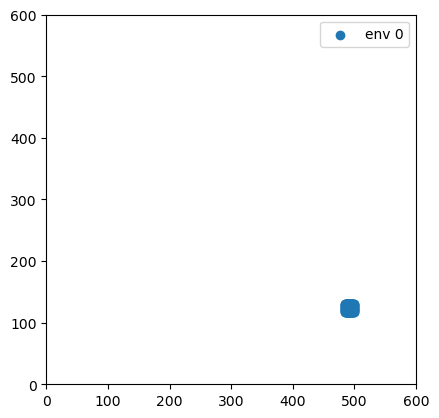

In [353]:
n_envs = 1
size = 15

used = []  # store placed (x, y)
C_pairs = []
max_tries = 10_000  # guard against infinite loops
touch_ok = False      # set False to forbid touching
tries = 0
while len(C_pairs) < n_envs and tries < max_tries:
    x = np.random.randint(0, Npos - size + 1)
    y = np.random.randint(0, Npos - size + 1)
    if all(not overlaps(x, y, px, py, size, touch_ok) for (px, py) in used):
        used.append((x, y))
        C_pairs.append((x, y))
    tries += 1

all_env_indices = []
goal_states = []
goal_locations = []

for env_idx in range(n_envs):
    C_X, C_Y = C_pairs[env_idx]
    x, y = np.meshgrid(np.arange(size), np.arange(size), indexing='ij')
    env_indices = np.stack((C_X + x, C_Y + y), axis=-1)
    all_env_indices.append(env_indices)

    flat_env = env_indices.reshape(-1, 2)
    goal_loc = flat_env[np.random.choice(len(flat_env))]
    goal_states.append(Phi[:, goal_loc[0], goal_loc[1]])
    goal_locations.append(goal_loc)

width, height = Npos, Npos

for env_idx in range(n_envs):
    env_indices = all_env_indices[env_idx]
    pos = env_indices.reshape(-1, 2)
    plt.scatter(pos[:, 0], pos[:, 1], label=f"env {env_idx}")

plt.xlim(0, width)
plt.ylim(0, height)
plt.gca().set_aspect('equal', adjustable='box')  # keep the aspect ratio square
plt.legend()
plt.show()

In [354]:
hop = Hopfield(num_units=embed_dim,beta=gain,device="cpu")
Phi_mem = torch.stack(goal_states).to(device)
Phi_mem_encoded = encoder(Phi_mem, gain=gain).detach().cpu()
for i in range(len(goal_states)):
    hop.input_memory(Phi_mem_encoded[i])

Random direction assignment (Env_N starts at base index 0):
  Env_N: (0, 1) ↑
  Env_E: (1, 0) →
  Env_S: (0, -1) ↓
  Env_W: (-1, 0) ←

=== Environment 0 (Method: discrete) ===
Start position (local): (13, 14)
Goal location (global): [486 122]
Recompute interval: 0 (never)
Trajectory length: 5 steps
Final position: [496 131]
Directions taken: ['Env_W', 'Env_W', 'Env_N', 'Env_S']


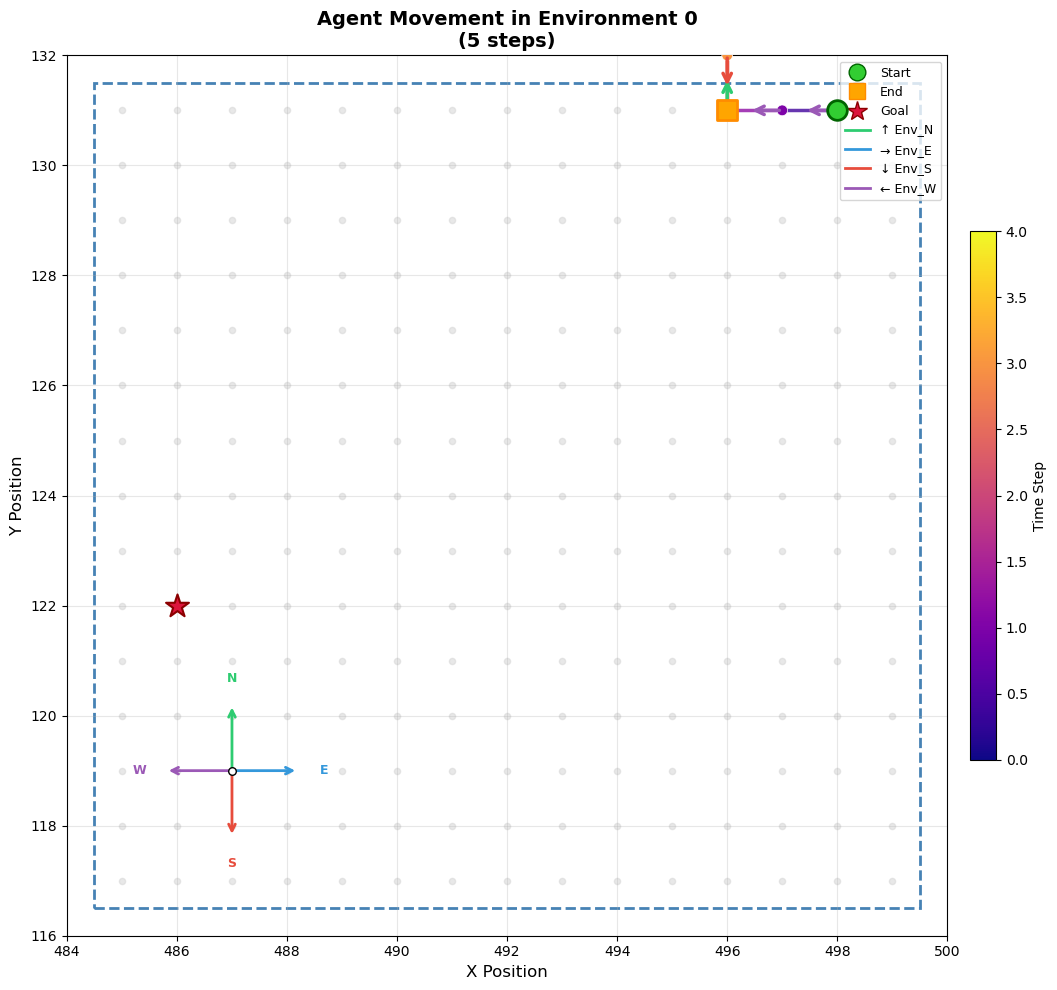

In [358]:
# Direction classification helpers
def compute_projection_matrix(d_forward, d_right):
    """Compute 2D projection matrix from forward/right basis vectors."""
    e1 = d_forward / np.linalg.norm(d_forward)
    e2 = d_right - np.dot(d_right, e1) * e1
    e2 = e2 / np.linalg.norm(e2)
    W = np.stack([e2, e1], axis=0)  # shape (2, n)
    return W

def project_query(W, d_query):
    """Project query vector into 2D space."""
    return W @ d_query  # shape (2,)

def classify_direction(q):
    """
    q: 2D vector [x, y]
    Returns: 0=Env_N, 1=Env_E, 2=Env_S, 3=Env_W
    """
    angle = np.arctan2(q[1], q[0])  # range: -pi to pi
    
    if -np.pi/4 <= angle < np.pi/4:
        return 1  # Env_E (right)
    elif np.pi/4 <= angle < 3*np.pi/4:
        return 0  # Env_N (forward)
    elif -3*np.pi/4 <= angle < -np.pi/4:
        return 2  # Env_S (backward)
    else:
        return 3  # Env_W (left)

# Randomly assign environment directions
# Base directions in CLOCKWISE order as they appear on plot: N, E, S, W
# On plot: y increases upward, x increases rightward
BASE_DIRECTIONS = [(0, 1), (1, 0), (0, -1), (-1, 0)]  # N(up), E(right), S(down), W(left)
BASE_ARROWS = ['↑', '→', '↓', '←']

# Randomly pick which physical direction is Env_N
ENV_N_INDEX = np.random.randint(0, 4)

# Map direction class to (dx, dy) offsets - assigned clockwise from Env_N
DIRECTION_ARROWS = {
    0: BASE_DIRECTIONS[ENV_N_INDEX],           # Env_N
    1: BASE_DIRECTIONS[(ENV_N_INDEX + 1) % 4], # Env_E (clockwise from N)
    2: BASE_DIRECTIONS[(ENV_N_INDEX + 2) % 4], # Env_S (opposite N)
    3: BASE_DIRECTIONS[(ENV_N_INDEX + 3) % 4], # Env_W (counter-clockwise from N)
}

# Arrow symbols for legend
DIRECTION_ARROW_SYMBOLS = {
    0: BASE_ARROWS[ENV_N_INDEX],
    1: BASE_ARROWS[(ENV_N_INDEX + 1) % 4],
    2: BASE_ARROWS[(ENV_N_INDEX + 2) % 4],
    3: BASE_ARROWS[(ENV_N_INDEX + 3) % 4],
}

print(f"Random direction assignment (Env_N starts at base index {ENV_N_INDEX}):")
print(f"  Env_N: {DIRECTION_ARROWS[0]} {DIRECTION_ARROW_SYMBOLS[0]}")
print(f"  Env_E: {DIRECTION_ARROWS[1]} {DIRECTION_ARROW_SYMBOLS[1]}")
print(f"  Env_S: {DIRECTION_ARROWS[2]} {DIRECTION_ARROW_SYMBOLS[2]}")
print(f"  Env_W: {DIRECTION_ARROWS[3]} {DIRECTION_ARROW_SYMBOLS[3]}")

DIRECTION_NAMES = {0: 'Env_N', 1: 'Env_E', 2: 'Env_S', 3: 'Env_W'}
DIRECTION_COLORS = {0: '#2ecc71', 1: '#3498db', 2: '#e74c3c', 3: '#9b59b6'}  # green, blue, red, purple


def draw_compass_rose(ax, center_x, center_y, size=1.0):
    """Draw a compass rose showing Env_N/E/S/W directions."""
    labels = ['N', 'E', 'S', 'W']
    
    for i in range(4):
        dx, dy = DIRECTION_ARROWS[i]
        color = DIRECTION_COLORS[i]
        
        # Draw arrow
        ax.annotate('', 
                    xy=(center_x + dx * size, center_y + dy * size),
                    xytext=(center_x, center_y),
                    arrowprops=dict(arrowstyle='->', color=color, lw=2, mutation_scale=12),
                    zorder=10)
        
        # Add label at arrow tip
        ax.text(center_x + dx * size * 1.4, center_y + dy * size * 1.4, 
                labels[i], ha='center', va='center', fontsize=9, fontweight='bold',
                color=color, zorder=10)
    
    # Draw center dot
    ax.scatter(center_x, center_y, c='white', s=30, edgecolors='black', linewidths=1, zorder=11)


def compute_projection_matrix_at_pos(pos):
    """
    Compute the projection matrix W at a given position based on local Env_N/Env_E directions.
    Returns W and the current encoded state at that position.
    """
    x, y = pos
    # Clamp to valid range for neighbor access
    x = np.clip(x, 1, encoded_Phi.shape[0] - 2)
    y = np.clip(y, 1, encoded_Phi.shape[1] - 2)
    
    current = encoded_Phi[x, y].numpy()
    
    # Get neighbor offsets from random direction assignment
    dn_dx, dn_dy = DIRECTION_ARROWS[0]  # Env_N direction
    de_dx, de_dy = DIRECTION_ARROWS[1]  # Env_E direction
    
    # d_forward is direction TO Env_N neighbor
    d_forward = encoded_Phi[x + dn_dx, y + dn_dy].numpy() - current
    # d_right is direction TO Env_E neighbor
    d_right = encoded_Phi[x + de_dx, y + de_dy].numpy() - current
    
    W = compute_projection_matrix(d_forward, d_right)
    return W, current


def classify_with_matrix(W, current_np, next_state_np):
    """
    Classify direction using a pre-computed projection matrix W.
    
    Args:
        W: Pre-computed projection matrix (2, embed_dim)
        current_np: Current encoded state (used to compute direction vector)
        next_state_np: Next state from Hopfield
    
    Returns:
        direction class and the raw 2D projected vector
    """
    d_query = next_state_np - current_np
    q = project_query(W, d_query)
    direction = classify_direction(q)
    return direction, q


def get_local_direction(pos, next_state_np):
    """
    Compute the classified direction at a position given the next Hopfield state.
    Returns direction class and the raw 2D projected vector.
    (Convenience function that computes W fresh each time)
    """
    W, current = compute_projection_matrix_at_pos(pos)
    return classify_with_matrix(W, current, next_state_np)


def simulate_trajectory(env_idx, start_x, start_y, max_steps=50, convergence_threshold=1e-3):
    """
    Simulate agent movement using Hopfield rollout.
    The Hopfield output state is used directly to find the next position via nearest neighbor search.
    """
    env_indices = all_env_indices[env_idx]
    goal_loc = goal_locations[env_idx]
    
    trajectory = []
    directions = []  # Store direction class at each step
    projected_vecs = []  # Store raw 2D projected vectors
    
    location = env_indices[start_x, start_y].copy()
    trajectory.append(location.copy())
    
    state = encoded_Phi[location[0], location[1]]
    
    for step in range(max_steps):
        next_state, _ = hop.recall(state, steps=1, beta=gain, alpha=0.9, use_tanh=True, normalize_each=True)
        
        # Compute direction classification
        direction, proj_vec = get_local_direction(location, next_state.numpy())
        directions.append(direction)
        projected_vecs.append(proj_vec)
        
        # Check for convergence
        if torch.norm(next_state - state) < convergence_threshold:
            break
            
        # Find closest position in encoded space
        sims = encoded_Phi @ next_state
        idx = torch.argmax(sims).item()
        row, col = divmod(idx, encoded_Phi.shape[1])
        
        location = np.array([row, col])
        trajectory.append(location.copy())
        state = next_state
        
        # Check if reached goal
        if np.array_equal(location, goal_loc):
            break
    
    return np.array(trajectory), directions, projected_vecs


# Map direction class to actual (dx, dy) step in grid coordinates (same as DIRECTION_ARROWS)
DIRECTION_STEPS = DIRECTION_ARROWS.copy()

def simulate_trajectory_discrete(env_idx, start_x, start_y, max_steps=50, bounds=None, recompute_interval=1):
    """
    Simulate agent movement using discrete stepping.
    
    1. Get Hopfield's next state from current encoded position
    2. Classify the direction (Env_N/Env_E/Env_S/Env_W)
    3. Take a discrete step in that direction
    4. Use the encoded state at the NEW physical position for next iteration
    
    Args:
        env_idx: Environment index
        start_x, start_y: Starting position (local coords within environment)
        max_steps: Maximum steps to take
        bounds: Optional (min_x, max_x, min_y, max_y) bounds, defaults to global encoded_Phi bounds
        recompute_interval: How often to recompute the projection matrix W.
                           1 = every step (default, same as before)
                           N = recompute every N steps
                           0 or negative = never recompute (use initial W for entire trajectory)
    """
    env_indices = all_env_indices[env_idx]
    goal_loc = goal_locations[env_idx]
    
    if bounds is None:
        min_x, max_x = 1, encoded_Phi.shape[0] - 2
        min_y, max_y = 1, encoded_Phi.shape[1] - 2
    else:
        min_x, max_x, min_y, max_y = bounds
    
    trajectory = []
    directions = []
    projected_vecs = []
    
    # Start position in global coordinates
    location = env_indices[start_x, start_y].copy()
    trajectory.append(location.copy())
    
    visited = set()
    visited.add(tuple(location))
    
    # Initialize projection matrix at start position
    W, W_origin_encoding = compute_projection_matrix_at_pos(location)
    steps_since_recompute = 0
    
    for step in range(max_steps):
        x, y = location
        
        # Get encoded state at CURRENT physical position
        state = encoded_Phi[x, y]
        current_np = state.numpy()
        
        # One Hopfield recall step
        next_state, _ = hop.recall(state, steps=1, beta=gain, alpha=0.85, use_tanh=True, normalize_each=True)
        
        # Check if we need to recompute the projection matrix
        if recompute_interval > 0 and steps_since_recompute >= recompute_interval:
            W, W_origin_encoding = compute_projection_matrix_at_pos(location)
            steps_since_recompute = 0
        
        # Classify direction using (possibly cached) projection matrix
        # Note: We use current_np for the direction vector, but W defines the coordinate frame
        direction, proj_vec = classify_with_matrix(W, current_np, next_state.numpy())
        directions.append(direction)
        projected_vecs.append(proj_vec)
        steps_since_recompute += 1
        
        # Take a discrete step in that direction
        dx, dy = DIRECTION_STEPS[direction] #finding which way globally is North - imagine Agent has an internal representation of this
        new_x = np.clip(x + dx, min_x, max_x)
        new_y = np.clip(y + dy, min_y, max_y)
        new_location = np.array([new_x, new_y])
        
        # Check if we're stuck (same position after step)
        if np.array_equal(new_location, location):
            break
            
        # Check for loops (optional: can disable if you want to allow revisiting)
        if tuple(new_location) in visited:
            # Still record the position but will break after
            trajectory.append(new_location.copy())
            break
        
        visited.add(tuple(new_location))
        location = new_location
        trajectory.append(location.copy())
        
        # Check if reached goal
        if np.array_equal(location, goal_loc):
            break
    
    return np.array(trajectory), directions, projected_vecs


def get_continuous_step(W, current_np, next_state_np, scale=1.0, normalize=False, floor=0.0):
    """
    Compute a continuous movement vector from the Hopfield direction.
    
    Args:
        W: Projection matrix (2, embed_dim)
        current_np: Current encoded state
        next_state_np: Next state from Hopfield
        scale: Scale factor for steps (default 1.0)
        normalize: If True, normalize the step to unit length * scale.
                   If False, use raw projection magnitude * scale.
        floor: Minimum step size. If step would be smaller, scale up to floor.
    
    Returns:
        (dx, dy): Step in grid coordinates
        angle: Angle relative to forward (0 = forward, positive = clockwise)
        magnitude: Raw magnitude of projected vector
    """
    d_query = next_state_np - current_np
    q = project_query(W, d_query)  # q[0] = right, q[1] = forward
    
    magnitude = np.linalg.norm(q)
    
    if magnitude < 1e-8:
        return (0.0, 0.0), 0.0, 0.0
    
    if normalize:
        # Normalize to unit vector, then scale
        q_scaled = (q / magnitude) * scale
    else:
        # Use raw magnitude
        q_scaled = q * scale
    
    # Apply floor: if step is too small, scale up to floor
    step_magnitude = np.linalg.norm(q_scaled)
    if floor > 0 and step_magnitude < floor:
        q_scaled = (q_scaled / step_magnitude) * floor

    # Convert q components to grid (dx, dy) using the actual direction vectors
    # q[0] = component along Env_E, q[1] = component along Env_N
    dn_dx, dn_dy = DIRECTION_ARROWS[0]  # Env_N direction
    de_dx, de_dy = DIRECTION_ARROWS[1]  # Env_E direction
    
    # This step is again, assuming the agent knows what North is in this environment (head direction cell)
    dx = q_scaled[0] * de_dx + q_scaled[1] * dn_dx
    dy = q_scaled[0] * de_dy + q_scaled[1] * dn_dy
    
    # Angle relative to forward (0 = forward, positive = turning right)
    angle_from_forward = np.arctan2(q[0], q[1])
    
    return (dx, dy), angle_from_forward, magnitude


def simulate_trajectory_continuous(env_idx, start_x, start_y, max_steps=100, 
                                   scale=1.0, normalize=False, floor=0.0, platform_radius=0.5,
                                   bounds=None, recompute_interval=1):
    """
    Simulate agent movement using continuous stepping.
    
    The Hopfield direction is projected onto a 2D plane, and the resulting
    vector determines the movement step.
    
    Args:
        env_idx: Environment index
        start_x, start_y: Starting position (local coords within environment)
        max_steps: Maximum steps to take
        scale: Scale factor for steps (default 1.0)
        normalize: If True, normalize steps to unit length * scale (fixed step size).
                   If False, use raw projection magnitude * scale (variable step size).
        floor: Minimum step size. Steps smaller than this get scaled up.
        platform_radius: Stop when within this distance of the goal (default 0.5)
        bounds: Optional (min_x, max_x, min_y, max_y) bounds
        recompute_interval: How often to recompute projection matrix W
    """
    env_indices = all_env_indices[env_idx]
    goal_loc = goal_locations[env_idx]
    
    if bounds is None:
        min_x, max_x = 1, encoded_Phi.shape[0] - 2
        min_y, max_y = 1, encoded_Phi.shape[1] - 2
    else:
        min_x, max_x, min_y, max_y = bounds
    
    trajectory = []  # Will store continuous (float) positions
    angles = []      # Angle at each step
    magnitudes = []  # Magnitude at each step
    
    # Start position in global coordinates (continuous)
    start_loc = env_indices[start_x, start_y].astype(float)
    position = start_loc.copy()
    trajectory.append(position.copy())
    
    # Initialize projection matrix at start position
    W, _ = compute_projection_matrix_at_pos(position.astype(int))
    steps_since_recompute = 0
    
    for step in range(max_steps):
        # Discretize position for encoding lookup
        grid_pos = np.clip(position.astype(int), [min_x, min_y], [max_x, max_y])
        
        # Get encoded state at current (discretized) position
        state = encoded_Phi[grid_pos[0], grid_pos[1]]
        current_np = state.numpy()
        
        # One Hopfield recall step
        next_state, _ = hop.recall(state, steps=1, beta=gain, alpha=0.85, 
                                   use_tanh=True, normalize_each=True)
        
        # Recompute projection matrix if needed
        if recompute_interval > 0 and steps_since_recompute >= recompute_interval:
            W, _ = compute_projection_matrix_at_pos(grid_pos)
            steps_since_recompute = 0
        
        # Get continuous step
        (dx, dy), angle, mag = get_continuous_step(W, current_np, next_state.numpy(), scale, normalize, floor)
        angles.append(angle)
        magnitudes.append(mag)
        steps_since_recompute += 1
        
        # Check for convergence (very small magnitude)
        if mag < 1e-6:
            break
        
        # Update position continuously
        new_position = position + np.array([dx, dy])
        
        # Clamp to bounds
        new_position[0] = np.clip(new_position[0], min_x, max_x)
        new_position[1] = np.clip(new_position[1], min_y, max_y)
        
        # Check if stuck
        if np.linalg.norm(new_position - position) < 1e-6:
            break
        
        position = new_position
        trajectory.append(position.copy())
        
        # Check if reached goal (within platform_radius)
        if np.linalg.norm(position - goal_loc) < platform_radius:
            break
    
    return np.array(trajectory), angles, magnitudes


def visualize_movement_continuous(env_idx, trajectory, angles, magnitudes, figsize=(12, 10)):
    """Visualize continuous agent movement with angle-based arrows."""
    env_indices = all_env_indices[env_idx]
    goal_loc = goal_locations[env_idx]
    C_X, C_Y = C_pairs[env_idx]
    
    fig, ax = plt.subplots(figsize=figsize)
    
    # Plot environment boundary
    env_bounds = plt.Rectangle((C_X - 0.5, C_Y - 0.5), size, size, 
                                fill=False, edgecolor='steelblue', linewidth=2, 
                                linestyle='--', label='Environment')
    ax.add_patch(env_bounds)
    
    # Plot all positions in environment (faint grid)
    pos = env_indices.reshape(-1, 2)
    ax.scatter(pos[:, 0], pos[:, 1], c='lightgray', s=20, alpha=0.5, zorder=1)
    
    traj = np.array(trajectory)
    
    # Create color gradient for trajectory (by time step)
    colors = plt.cm.plasma(np.linspace(0.1, 0.9, len(traj)))
    
    # Plot trajectory line with gradient
    for i in range(len(traj) - 1):
        ax.plot(traj[i:i+2, 0], traj[i:i+2, 1], 
                color=colors[i], linewidth=2.5, alpha=0.8, zorder=2)
    
    # Plot trajectory points colored by step number
    ax.scatter(traj[:, 0], traj[:, 1], c=np.arange(len(traj)), cmap='plasma', 
               s=60, edgecolors='white', linewidths=0.5, zorder=3)
    
    # Draw arrows showing movement direction (based on angle)
    arrow_scale = 0.5
    dn_dx, dn_dy = DIRECTION_ARROWS[0]  # Env_N direction
    de_dx, de_dy = DIRECTION_ARROWS[1]  # Env_E direction
    
    for i in range(min(len(traj) - 1, len(angles))):
        angle = angles[i]
        # angle is relative to forward (Env_N), so:
        # forward_component = cos(angle), right_component = sin(angle)
        # Convert to grid coords using direction vectors
        adx = (np.cos(angle) * dn_dx + np.sin(angle) * de_dx) * arrow_scale
        ady = (np.cos(angle) * dn_dy + np.sin(angle) * de_dy) * arrow_scale
        
        ax.annotate('', 
                    xy=(traj[i, 0] + adx, traj[i, 1] + ady),
                    xytext=(traj[i, 0], traj[i, 1]),
                    arrowprops=dict(arrowstyle='->', color='dodgerblue', lw=1.5, 
                                    mutation_scale=12),
                    zorder=6)
    
    # Mark start, end, goal
    ax.scatter(traj[0, 0], traj[0, 1], c='limegreen', s=200, marker='o', 
               edgecolors='darkgreen', linewidths=2, zorder=7, label='Start')
    ax.scatter(traj[-1, 0], traj[-1, 1], c='orange', s=200, marker='s', 
               edgecolors='darkorange', linewidths=2, zorder=7, label='End')
    ax.scatter(goal_loc[0], goal_loc[1], c='crimson', s=300, marker='*', 
               edgecolors='darkred', linewidths=1.5, zorder=4, label='Goal')
    
    # Formatting
    padding = 1
    ax.set_xlim(C_X - padding, C_X + size)
    ax.set_ylim(C_Y - padding, C_Y + size)
    ax.set_aspect('equal')
    ax.set_xlabel('X Position', fontsize=12)
    ax.set_ylabel('Y Position', fontsize=12)
    ax.set_title(f'Continuous Movement in Environment {env_idx}\n({len(traj)} steps)', 
                 fontsize=14, fontweight='bold')
    ax.legend(loc='upper right', fontsize=9)
    ax.grid(True, alpha=0.3)
    
    # Add compass rose in lower-left
    compass_x = C_X + 2
    compass_y = C_Y + 2
    draw_compass_rose(ax, compass_x, compass_y, size=1.2)
    
    # Colorbar for time step
    sm = plt.cm.ScalarMappable(cmap='plasma', norm=plt.Normalize(0, len(traj)-1))
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax, shrink=0.6, pad=0.02)
    cbar.set_label('Time Step', fontsize=10)
    
    plt.tight_layout()
    return fig, ax


def visualize_movement(env_idx, trajectory, directions, projected_vecs=None, figsize=(12, 10)):
    """Visualize agent movement within environment with direction arrows."""
    env_indices = all_env_indices[env_idx]
    goal_loc = goal_locations[env_idx]
    C_X, C_Y = C_pairs[env_idx]
    
    fig, ax = plt.subplots(figsize=figsize)
    
    # Plot environment boundary
    env_bounds = plt.Rectangle((C_X - 0.5, C_Y - 0.5), size, size, 
                                fill=False, edgecolor='steelblue', linewidth=2, linestyle='--', label='Environment')
    ax.add_patch(env_bounds)
    
    # Plot all positions in environment (faint grid)
    pos = env_indices.reshape(-1, 2)
    ax.scatter(pos[:, 0], pos[:, 1], c='lightgray', s=20, alpha=0.5, zorder=1)
    
    # Plot trajectory
    traj = np.array(trajectory)
    
    # Create color gradient for trajectory (dark to light)
    colors = plt.cm.plasma(np.linspace(0.1, 0.9, len(traj)))
    
    # Plot trajectory line with gradient
    for i in range(len(traj) - 1):
        ax.plot(traj[i:i+2, 0], traj[i:i+2, 1], 
                color=colors[i], linewidth=2.5, alpha=0.8, zorder=2)
    
    # Plot trajectory points
    ax.scatter(traj[:, 0], traj[:, 1], c=np.arange(len(traj)), cmap='plasma', 
               s=60, edgecolors='white', linewidths=0.5, zorder=3)
    
    # Draw direction arrows at each trajectory point
    arrow_scale = 0.6  # Scale factor for arrow length
    for i, (point, direction) in enumerate(zip(traj[:-1], directions)):  # Skip last point (no next state)
        dx, dy = DIRECTION_ARROWS[direction]
        arrow_color = DIRECTION_COLORS[direction]
        
        ax.annotate('', 
                    xy=(point[0] + dx * arrow_scale, point[1] + dy * arrow_scale),
                    xytext=(point[0], point[1]),
                    arrowprops=dict(arrowstyle='->', color=arrow_color, lw=2.5, 
                                    mutation_scale=15),
                    zorder=6)
    
    # Mark start position
    ax.scatter(traj[0, 0], traj[0, 1], c='limegreen', s=200, marker='o', 
               edgecolors='darkgreen', linewidths=2, zorder=7, label='Start')
    
    # Mark end position
    ax.scatter(traj[-1, 0], traj[-1, 1], c='orange', s=200, marker='s', 
               edgecolors='darkorange', linewidths=2, zorder=7, label='End')
    
    # Mark goal position
    ax.scatter(goal_loc[0], goal_loc[1], c='crimson', s=300, marker='*', 
               edgecolors='darkred', linewidths=1.5, zorder=4, label='Goal')
    
    # Formatting
    padding = 1
    ax.set_xlim(C_X - padding, C_X + size)
    ax.set_ylim(C_Y - padding, C_Y + size)
    ax.set_aspect('equal')
    ax.set_xlabel('X Position', fontsize=12)
    ax.set_ylabel('Y Position', fontsize=12)
    ax.set_title(f'Agent Movement in Environment {env_idx}\n({len(traj)} steps)', fontsize=14, fontweight='bold')
    
    # Custom legend with direction colors
    legend_elements = [
        Line2D([0], [0], marker='o', color='w', markerfacecolor='limegreen', 
               markeredgecolor='darkgreen', markersize=12, label='Start'),
        Line2D([0], [0], marker='s', color='w', markerfacecolor='orange', 
               markeredgecolor='darkorange', markersize=12, label='End'),
        Line2D([0], [0], marker='*', color='w', markerfacecolor='crimson', 
               markeredgecolor='darkred', markersize=15, label='Goal'),
        Line2D([0], [0], color=DIRECTION_COLORS[0], lw=2, label=f'{DIRECTION_ARROW_SYMBOLS[0]} Env_N'),
        Line2D([0], [0], color=DIRECTION_COLORS[1], lw=2, label=f'{DIRECTION_ARROW_SYMBOLS[1]} Env_E'),
        Line2D([0], [0], color=DIRECTION_COLORS[2], lw=2, label=f'{DIRECTION_ARROW_SYMBOLS[2]} Env_S'),
        Line2D([0], [0], color=DIRECTION_COLORS[3], lw=2, label=f'{DIRECTION_ARROW_SYMBOLS[3]} Env_W'),
    ]
    ax.legend(handles=legend_elements, loc='upper right', fontsize=9)
    ax.grid(True, alpha=0.3)
    
    # Add compass rose in lower-left
    compass_x = C_X + 2
    compass_y = C_Y + 2
    draw_compass_rose(ax, compass_x, compass_y, size=1.2)
    
    # Add colorbar for time
    sm = plt.cm.ScalarMappable(cmap='plasma', norm=plt.Normalize(0, len(traj)-1))
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax, shrink=0.6, pad=0.02)
    cbar.set_label('Time Step', fontsize=10)
    
    plt.tight_layout()
    return fig, ax


# Choose simulation method: 'hopfield', 'discrete', or 'continuous'
# - 'hopfield': Uses Hopfield output state directly to find next position (nearest neighbor)
# - 'discrete': Classifies direction from Hopfield output, takes discrete step (±1), uses new position's encoding
# - 'continuous': Uses projection magnitude directly for continuous movement steps
METHOD = 'discrete'  # Change to 'hopfield', 'discrete', or 'continuous'

# For 'discrete' and 'continuous' methods: how often to recompute the projection matrix W
# - 1 = every step (recompute at each new position, default behavior)
# - N = every N steps (use same W for N steps before recomputing)
# - 0 = never (use initial W from start position for entire trajectory)
RECOMPUTE_INTERVAL = 0

# For 'continuous' method:
SCALE = 1.0          # Scale factor for steps
NORMALIZE = True      # If True: fixed step size (unit direction * scale)
                       # If False: variable step size (raw magnitude * scale)
FLOOR = 1              # Minimum step size (0 = no floor)
PLATFORM_RADIUS = 1  # Stop when within this distance of goal

# Run simulation and visualize for each environment
for env_idx in range(n_envs):
    # Random start position within environment
    start_x = np.random.randint(0, size)
    start_y = np.random.randint(0, size)
    
    print(f"\n=== Environment {env_idx} (Method: {METHOD}) ===")
    print(f"Start position (local): ({start_x}, {start_y})")
    print(f"Goal location (global): {goal_locations[env_idx]}")
    
    if METHOD == 'hopfield':
        trajectory, directions, projected_vecs = simulate_trajectory(env_idx, start_x, start_y, max_steps=100)
        print(f"Trajectory length: {len(trajectory)} steps")
        print(f"Final position: {trajectory[-1]}")
        print(f"Directions taken: {[DIRECTION_NAMES[d] for d in directions]}")
        visualize_movement(env_idx, trajectory, directions, projected_vecs)
        
    elif METHOD == 'discrete':
        print(f"Recompute interval: {RECOMPUTE_INTERVAL} {'(every step)' if RECOMPUTE_INTERVAL == 1 else '(never)' if RECOMPUTE_INTERVAL <= 0 else f'(every {RECOMPUTE_INTERVAL} steps)'}")
        trajectory, directions, projected_vecs = simulate_trajectory_discrete(
            env_idx, start_x, start_y, max_steps=100, recompute_interval=RECOMPUTE_INTERVAL
        )
        print(f"Trajectory length: {len(trajectory)} steps")
        print(f"Final position: {trajectory[-1]}")
        print(f"Directions taken: {[DIRECTION_NAMES[d] for d in directions]}")
        visualize_movement(env_idx, trajectory, directions, projected_vecs)
        
    else:  # continuous
        print(f"Recompute interval: {RECOMPUTE_INTERVAL}, Scale: {SCALE}, Normalize: {NORMALIZE}, Floor: {FLOOR}, Platform radius: {PLATFORM_RADIUS}")
        trajectory, angles, magnitudes = simulate_trajectory_continuous(
            env_idx, start_x, start_y, max_steps=100, scale=SCALE, normalize=NORMALIZE, floor=FLOOR, 
            platform_radius=PLATFORM_RADIUS, recompute_interval=RECOMPUTE_INTERVAL
        )
        print(f"Trajectory length: {len(trajectory)} steps")
        print(f"Final position: {trajectory[-1]}")
        print(f"Magnitudes (first 10): {[f'{m:.4f}' for m in magnitudes[:10]]}")
        visualize_movement_continuous(env_idx, trajectory, angles, magnitudes)
    
    plt.show()